<a href="https://colab.research.google.com/github/ClaudiaTurner/GEOG5990M/blob/main/Final_Project_Python_GEOG5990M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEOG5990M Final Assignment (Template)

Student ID number: 201893759

In [ ]:
# read in required packages

This is an example block of mardown text I want to reference <a href="#ref1">[1]</a>. I might need to add some more citations <a href="#ref2">[2]</a><a href="#ref2">[3]</a>



Data Visualisation
- Don't forget to present your final two data visualisation (one spatial and one non-spatial) and the justifications about the decisions you made whilst preparing and visualising the data.

**PACKAGE IMPORTS & DATA LOADING**

In [1]:
# To begin, I will import the packages I will use in block 1. These include:

import pandas as pd  # Used for uploading and handling data (e.g., upload CSV) (Nelli, 2023).

import matplotlib.pyplot as plt  # Used for creating visualisations (e.g., line chart) (Walker, 2020).

import numpy as np  # Used for numerical operations (e.g., create a range of years) (Walker, 2020).

import seaborn as sns  # Makes it easier to create attractive and informative statistical graphics (e.g., barplot) (Rajagopalan,2021)

from matplotlib import colormaps  # ✅ Modern import for colorblind-safe colormaps


In [2]:
# The DataFrame we will use contains information on number of house sales from 1996 to 2023, across all districts in England. Our analysis will cover 2000 to 2023.
# To upload the data (CSV), I’ll paste the GitHub file path below:
Sales_England=pd.read_csv('https://github.com/ClaudiaTurner/GEOG5990M/raw/main/DATA/Eng_sales_1996_2023_.csv')


# To understand the data better, I'll take a quick look at the first six rows
display(Sales_England.head(6))

# I added row and column info below the table, with a title and a line break for clarity.
print('\nNumber of rows and columns:')
print(Sales_England.shape)


,Residential property sales,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30
0,ONS Crown Copyright Reserved [from Nomis on 9 ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Count of sales:,Sales,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Area,mnemonic,row,Sep-96,Sep-97,Sep-98,Sep-99,Sep-00,Sep-01,Sep-02,...,Sep-14,Sep-15,Sep-16,Sep-17,Sep-18,Sep-19,Sep-20,Sep-21,Sep-22,Sep-23
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,country:England,E92000001,1,850013,1047268,1016037,1084672,1130983,1133620,1271168,...,877425,854379,903005,852771,829715,803012,669410,1081660,787290,573646



Number of rows and columns:
(324, 31)


**DATA CLEANING**

In [3]:
# The original CSV had extra information in rows 1, 2, 3, and 4, making the data messy.
# For example, 'Unnamed: 1' was just a blank row in the original file.
# The column titles should be in the fifth row e.g.: like 'Sep-96', 'Area', etc.

## To clean the data, I will start by removing the first four rows using the 'skiprows' function (Walker, 2020).
## This will eliminate everything above the actual headers.
Sales_England = pd.read_csv('https://github.com/ClaudiaTurner/GEOG5990M/raw/main/Sales_1995_2023_England_Districts_exp.csv', skiprows=4)

# Confirm the changes
Sales_England.head()


,row,Sep-96,Sep-97,Sep-98,Sep-99,Sep-00,Sep-01,Sep-02,Sep-03,Sep-04,...,Sep-16,Sep-17,Sep-18,Sep-19,Sep-20,Sep-21,Sep-22,Sep-23,Area,mnemonic
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,850013.0,1047268.0,1016037.0,1084672.0,1130983.0,1133620.0,1271168.0,1153345.0,1264229.0,...,903005.0,852771.0,829715.0,803012.0,669410.0,1081660.0,787290.0,573646.0,country:England,E92000001
2,2.0,1159.0,1390.0,1405.0,1440.0,1726.0,2140.0,2359.0,2488.0,2979.0,...,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0,1103.0,ladu2023:Hartlepool,E06000001
3,3.0,1776.0,1934.0,1948.0,2055.0,2280.0,2462.0,2826.0,3016.0,3339.0,...,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0,1298.0,ladu2023:Middlesbrough,E06000002
4,4.0,1879.0,2000.0,1957.0,1986.0,2266.0,2582.0,3497.0,3390.0,3138.0,...,1824.0,1947.0,2007.0,1967.0,1636.0,2539.0,2081.0,1667.0,ladu2023:Redcar and Cleveland,E06000003


In [4]:
# Our analysis should include years (2000 - 2023), hence we can eliminate the rest of the years
# Additionally, we also eliminate 'row' because we already have the table's row enumeration
Sales_England = Sales_England.drop(columns=[
    'row', 'Sep-96', 'Sep-97', 'Sep-98', 'Sep-99',])

# After eliminating many columns, ill check if the columns were successfully eliminated
Sales_England.columns.tolist()   # .tolist() converts the column index into a regular Python list

['Sep-00',
 'Sep-01',
 'Sep-02',
 'Sep-03',
 'Sep-04',
 'Sep-05',
 'Sep-06',
 'Sep-07',
 'Sep-08',
 'Sep-09',
 'Sep-10',
 'Sep-11',
 'Sep-12',
 'Sep-13',
 'Sep-14',
 'Sep-15',
 'Sep-16',
 'Sep-17',
 'Sep-18',
 'Sep-19',
 'Sep-20',
 'Sep-21',
 'Sep-22',
 'Sep-23',
 'Area',
 'mnemonic']

In [5]:
# RENAME COLUMNS

#To further clean and enhance the data, I'll rename and reorder the columns.
# I'll also change the date format from 'Sep-13' to '2013' for all years to improve readability. # To update the file, I can use either 'Sales_England =' or set 'inplace=True'.

Sales_England = Sales_England.rename(columns={
  'Sep-00':'2000','Sep-01':'2001', 'Sep-02':'2002', 'Sep-03':'2003', 'Sep-04':'2004',
    'Sep-05':'2005', 'Sep-06':'2006', 'Sep-07':'2007', 'Sep-08':'2008', 'Sep-09':'2009',
    'Sep-10':'2010', 'Sep-11':'2011', 'Sep-12':'2012','Sep-13': '2013', 'Sep-14': '2014', 'Sep-15': '2015', 'Sep-16': '2016', 'Sep-17': '2017',
    'Sep-18': '2018','Sep-19': '2019','Sep-20': '2020','Sep-21': '2021','Sep-22': '2022','Sep-23': '2023','Area': 'DISTRICT','mnemonic': 'CODE_LAD'})

#REORDER COLUMNS

# 2. Reorder the columns so that the district name and code appear before the years.
# After runing this code: 'Sales_England = Sales_England[['DISTRICT', 'CODE_LAD'] + [str(y) for y in range(2000, 2023)]]', year 2023 disappeared
## Thus I asked Copilot (ADD VERSION): 'After introducing the code, year 2023 is not visible, why?'
## Copilot:  in Python, range(...) excludes the end value, so 2023 is not included.

Sales_England = Sales_England[['DISTRICT', 'CODE_LAD'] + [str(y) for y in range(2000, 2024)]]


# Check the last 5 rows to confirm changes.
Sales_England.tail()


,DISTRICT,CODE_LAD,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
315,ladu2023:Torfaen,W06000020,1461.0,1438.0,1612.0,1511.0,1482.0,1079.0,1488.0,1695.0,...,1091.0,985.0,1103.0,1324.0,1438.0,1464.0,1060.0,1520.0,1392.0,928.0
316,ladu2023:Monmouthshire,W06000021,2038.0,1867.0,2038.0,1696.0,2082.0,1433.0,1543.0,1739.0,...,1413.0,1399.0,1584.0,1557.0,1482.0,1307.0,1054.0,1936.0,1556.0,1030.0
317,ladu2023:Newport,W06000022,2856.0,2935.0,3464.0,3003.0,3101.0,2396.0,2938.0,2757.0,...,2016.0,2178.0,2761.0,3021.0,2869.0,2503.0,1798.0,2634.0,2440.0,1763.0
318,ladu2023:Powys,W06000023,2048.0,2094.0,2101.0,2179.0,2341.0,1734.0,2066.0,2279.0,...,1650.0,1635.0,1743.0,1827.0,1880.0,1802.0,1383.0,2394.0,1831.0,1284.0
319,ladu2023:Merthyr Tydfil,W06000024,762.0,779.0,1000.0,1016.0,1061.0,840.0,977.0,1006.0,...,683.0,706.0,786.0,745.0,682.0,725.0,577.0,818.0,781.0,527.0


In [ ]:
# Search for null values and delete them to enhance clarity

#Search for null values
# Explain why we have null values
Sales_England.isnull().sum()

,0
DISTRICT,1
CODE_LAD,1
2000,1
2001,1
2002,1
2003,1
2004,1
2005,1
2006,1
2007,1


In [6]:
# Eliminate null values.............. Why do you eliminate them?
Sales_England = Sales_England.dropna()

# .info() shows column names, data types, non-null counts, and memory usage (Walker, 2020.
Sales_England.head(3)

,DISTRICT,CODE_LAD,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,country:England,E92000001,1130983.0,1133620.0,1271168.0,1153345.0,1264229.0,976245.0,1203858.0,1279204.0,...,877425.0,854379.0,903005.0,852771.0,829715.0,803012.0,669410.0,1081660.0,787290.0,573646.0
2,ladu2023:Hartlepool,E06000001,1726.0,2140.0,2359.0,2488.0,2979.0,2123.0,2285.0,2290.0,...,1113.0,1205.0,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0,1103.0
3,ladu2023:Middlesbrough,E06000002,2280.0,2462.0,2826.0,3016.0,3339.0,2817.0,3139.0,3514.0,...,1556.0,1748.0,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0,1298.0


In [7]:
# ELIMINATE A ROW: We're removing the first row (country:England) because the data is unclear and not useful for our analysis.

# Drop the first row (Country: England) by specifying its index.
# Later on, we'll create a new row to calculate the total amount per year. index[0] selects the first row in the table.

Sales_England = Sales_England.drop(Sales_England.index[0]).reset_index(drop=True) # .reset_index(drop=True) resets row numbering to start at 0
                                                                                  # e.g., instead of index 1, 2, 3... → becomes 0, 1, 2...

# The first row has now been removed. Check the first 3 rows to confirm.
Sales_England.head(3)


,DISTRICT,CODE_LAD,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,ladu2023:Hartlepool,E06000001,1726.0,2140.0,2359.0,2488.0,2979.0,2123.0,2285.0,2290.0,...,1113.0,1205.0,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0,1103.0
1,ladu2023:Middlesbrough,E06000002,2280.0,2462.0,2826.0,3016.0,3339.0,2817.0,3139.0,3514.0,...,1556.0,1748.0,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0,1298.0
2,ladu2023:Redcar and Cleveland,E06000003,2266.0,2582.0,3497.0,3390.0,3138.0,2406.0,2945.0,3376.0,...,1918.0,1773.0,1824.0,1947.0,2007.0,1967.0,1636.0,2539.0,2081.0,1667.0


In [8]:
# MODIFY ROWS names with the 'DISTRICT' column

# Aditionally, I'll remove the 'ladu2023:' prefix from all values in the 'DISTRICT' column to clean up the district names.

Sales_England['DISTRICT'] = Sales_England['DISTRICT'].str.replace('ladu2023:', '')

# The prefix in the district names is no longer visible. Briefly check the first 5 rowa
Sales_England.head()

,DISTRICT,CODE_LAD,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Hartlepool,E06000001,1726.0,2140.0,2359.0,2488.0,2979.0,2123.0,2285.0,2290.0,...,1113.0,1205.0,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0,1103.0
1,Middlesbrough,E06000002,2280.0,2462.0,2826.0,3016.0,3339.0,2817.0,3139.0,3514.0,...,1556.0,1748.0,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0,1298.0
2,Redcar and Cleveland,E06000003,2266.0,2582.0,3497.0,3390.0,3138.0,2406.0,2945.0,3376.0,...,1918.0,1773.0,1824.0,1947.0,2007.0,1967.0,1636.0,2539.0,2081.0,1667.0
3,Stockton-on-Tees,E06000004,3978.0,4168.0,5320.0,4610.0,4471.0,3293.0,4341.0,4901.0,...,2724.0,2685.0,2922.0,2959.0,3090.0,3066.0,2523.0,3826.0,3063.0,2186.0
4,Darlington,E06000005,2538.0,2770.0,3033.0,2926.0,3288.0,2287.0,2771.0,3033.0,...,1589.0,1705.0,1679.0,1642.0,1602.0,1616.0,1501.0,2435.0,1885.0,1339.0


**NEW VARIABLES: DATA EXPLORATION & VISUALISATION**

In [9]:
# CALCULATE TOTAL SALES PER DISTRICT (2000–2023) TO IDENTIFY DISTRICTS WITH THE MOST AND LEAST SALES

# 1. Identify year columns by selecting only numerical columns (type float64),
# which correspond to annual sales data. This excludes non-numerical metadata columns
# like 'DISTRICT' and 'CODE_LAD' automatically.

year_columns = Sales_England.select_dtypes(include='number').columns

# 2. Sum across the selected year columns (per row) to calculate the total number of sales
# for each district (LAD) across all years.
# axis=1 means the operation is performed **horizontally across columns** (i.e., across years for each row).

Sales_England['TOTAL_SALES_LAD'] = Sales_England[year_columns].sum(axis=1)

Sales_England.head(4)

,DISTRICT,CODE_LAD,2000,2001,2002,2003,2004,2005,2006,2007,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,TOTAL_SALES_LAD
0,Hartlepool,E06000001,1726.0,2140.0,2359.0,2488.0,2979.0,2123.0,2285.0,2290.0,...,1205.0,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0,1103.0,36918.0
1,Middlesbrough,E06000002,2280.0,2462.0,2826.0,3016.0,3339.0,2817.0,3139.0,3514.0,...,1748.0,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0,1298.0,49516.0
2,Redcar and Cleveland,E06000003,2266.0,2582.0,3497.0,3390.0,3138.0,2406.0,2945.0,3376.0,...,1773.0,1824.0,1947.0,2007.0,1967.0,1636.0,2539.0,2081.0,1667.0,51496.0
3,Stockton-on-Tees,E06000004,3978.0,4168.0,5320.0,4610.0,4471.0,3293.0,4341.0,4901.0,...,2685.0,2922.0,2959.0,3090.0,3066.0,2523.0,3826.0,3063.0,2186.0,78308.0


In [10]:
# CALCULATE AVERAGE SALES FOR ALL DISTRICTS

# 1. Dynamically find all year columns between 2000 and 2023.
# This avoids hardcoding and ensures the list only includes numeric year labels.
year_cols = [col for col in Sales_England.columns if col.isdigit() and 2000 <= int(col) <= 2023]

# 2. Calculate the row-wise average across those year columns (i.e., for each district)
# axis=1 means we're averaging values horizontally, across the years for each district.
Sales_England['AVERAGE'] = Sales_England[year_cols].mean(axis=1)

# 3. Round the average to 1 decimal place for easier readability
Sales_England['AVERAGE'] = Sales_England['AVERAGE'].round(0)

# 4. Preview the result
Sales_England.head(4)

,DISTRICT,CODE_LAD,2000,2001,2002,2003,2004,2005,2006,2007,...,2016,2017,2018,2019,2020,2021,2022,2023,TOTAL_SALES_LAD,AVERAGE
0,Hartlepool,E06000001,1726.0,2140.0,2359.0,2488.0,2979.0,2123.0,2285.0,2290.0,...,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0,1103.0,36918.0,1538.0
1,Middlesbrough,E06000002,2280.0,2462.0,2826.0,3016.0,3339.0,2817.0,3139.0,3514.0,...,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0,1298.0,49516.0,2063.0
2,Redcar and Cleveland,E06000003,2266.0,2582.0,3497.0,3390.0,3138.0,2406.0,2945.0,3376.0,...,1824.0,1947.0,2007.0,1967.0,1636.0,2539.0,2081.0,1667.0,51496.0,2146.0
3,Stockton-on-Tees,E06000004,3978.0,4168.0,5320.0,4610.0,4471.0,3293.0,4341.0,4901.0,...,2922.0,2959.0,3090.0,3066.0,2523.0,3826.0,3063.0,2186.0,78308.0,3263.0


<ipython-input-16-5494bbd07b76>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TOTAL_SALES_LAD', y='DISTRICT', data=top_avg_districts, palette=colors)                                # Plot horizontal bar chart


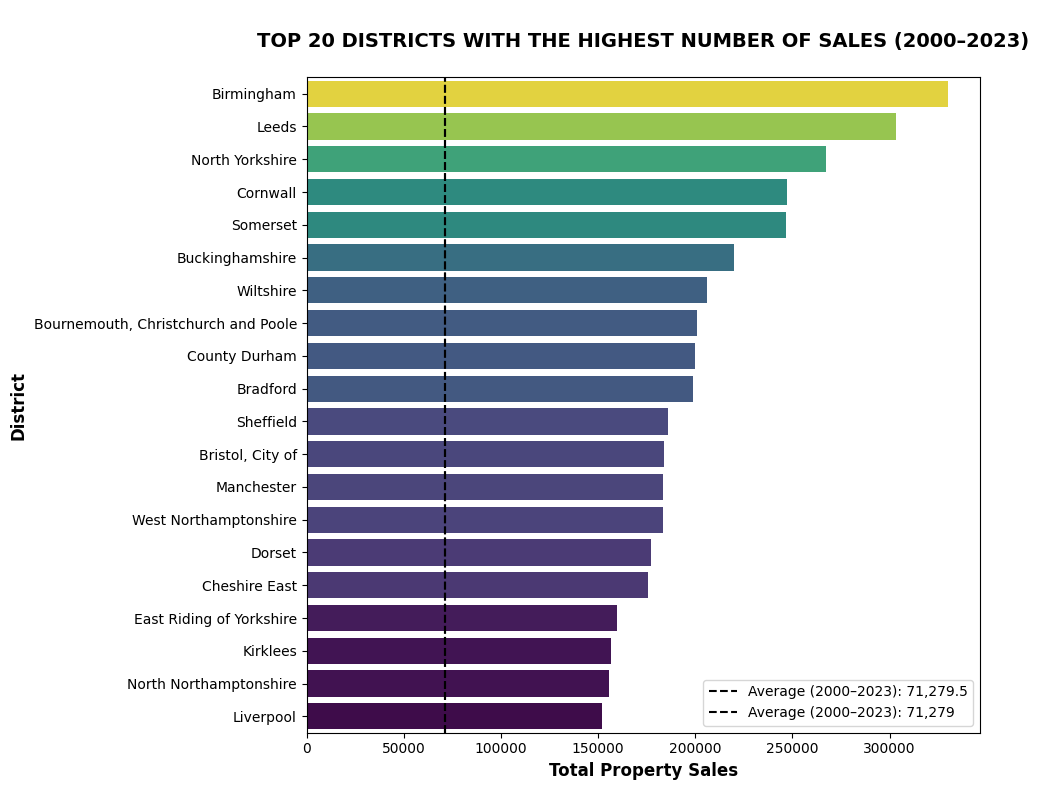

In [16]:
# NON-SPATIAL DATA VISUALISATION:
# This visualisation aims to inform the public and stakeholders about
# the number of houses sold per district, along with the national average.

# 1. Sort by total sales and get top 20 districts
top_avg_districts = Sales_England.sort_values('TOTAL_SALES_LAD', ascending=False).head(20)                           # Get top 20 LADs by total sales

# 2. Calculate national average across all districts
avg_sales = Sales_England['TOTAL_SALES_LAD'].mean()                                                                  # Compute mean total sales across all districts (not just top 20)

# 3. Create a colorblind-friendly gradient using 'viridis'
norm = plt.Normalize(top_avg_districts['TOTAL_SALES_LAD'].min(), top_avg_districts['TOTAL_SALES_LAD'].max())          # Normalize values for color scale
cmap = colormaps['viridis']                                                                                           # Choose a perceptually uniform, colorblind-safe colormap
colors = [cmap(norm(val)) for val in top_avg_districts['TOTAL_SALES_LAD']]                                            # Map each district's total sales to a color

# 4. Create the bar plot
plt.figure(figsize=(10, 8))                                                                                           # Set figure size (width x height in inches)
sns.barplot(x='TOTAL_SALES_LAD', y='DISTRICT', data=top_avg_districts, palette=colors)                                # Plot horizontal bar chart

# 5. Add a vertical line to show the national average
plt.axvline(avg_sales, color='black', linestyle='--', linewidth=1.5, label=f"Average (2000–2023): {avg_sales:,.1f}")  # Add average line
# 6. Add vertical line for national average
plt.axvline(avg_sales, color='black', linestyle='--', linewidth=1.5, label=f"Average (2000–2023): {int(avg_sales):,}")

# 7. Customize labels and legend
plt.title("\nTOP 20 DISTRICTS WITH THE HIGHEST NUMBER OF SALES (2000–2023)\n", fontsize=14, fontweight='bold')  # Main title
plt.xlabel("Total Property Sales", fontsize=12, fontweight='bold')    # X-axis label
plt.ylabel("District", fontsize=12, fontweight='bold')                # Y-axis label
plt.legend(loc='lower right')                                         # Show legend for the average line
plt.tight_layout()                                                    # Prevent clipping of labels/titles
plt.show()                                                            # Render the plot

In [ ]:
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
<ipython-input-11-3eb84359ae51> in <cell line: 0>()
      2
      3 # 2. Sort by total and get top 20
----> 4 top_avg_districts = filtered_sales.sort_values('TOTAL_SALES_LAD', ascending=False).head(20)
      5
      6 # 3. Calculate average total sales across all districts

NameError: name 'filtered_sales' is not defined


In [44]:
# Briefly take a quick glance to view the districts with the lowest amount of sales.

# Bottom 20 districts by total property sales
print("\n🔻 Bottom 5 Districts by Total Property Sales:\n\n Note all districts sales are below the average\n")
print(Sales_England.nsmallest(20, 'TOTAL_SALES_LAD')[['DISTRICT', 'TOTAL_SALES_LAD']])
print("\nNote that all district sales are below the average.")



🔻 Bottom 5 Districts by Total Property Sales:

 Note all districts sales are below the average

               DISTRICT  TOTAL_SALES_LAD
277     Isles of Scilly            441.0
172      City of London           6635.0
64              Rutland          17074.0
317      Merthyr Tydfil          17607.0
312       Blaenau Gwent          20159.0
82    Oadby and Wigston          20541.0
80               Melton          21195.0
302          Ceredigion          22713.0
109  North Warwickshire          23323.0
288          West Devon          24273.0
296    Isle of Anglesey          24834.0
27        Ribble Valley          25598.0
71     Derbyshire Dales          27618.0
262                Adur          27807.0
146              Maldon          27885.0
83               Boston          27895.0
108            Tamworth          28713.0
115       Malvern Hills          29050.0
313             Torfaen          29053.0
28           Rossendale          29088.0

Note all districts sales are below the av

In [50]:
# NEW ROW: TOTAL SALES AMOUNT PER YEAR IN ENGLAND

# This section adds a new row that sums the total property sales across all districts,
# for each year and for the entire dataset. The row will help visualize or compare
# national-level trends vs. individual districts.

# 1. Identify which columns are numeric (i.e., actual sales figures for each year),
# and which are non-numeric (e.g., 'DISTRICT', 'CODE_LAD', etc.)
numeric_cols = Sales_England.select_dtypes(include='number').columns
non_numeric_cols = [col for col in Sales_England.columns if col not in numeric_cols]

# 2. Sum all sales data across numeric columns (i.e., total number of properties sold per year)
england_totals = Sales_England[numeric_cols].sum()

# 3. For the non-numeric fields like 'DISTRICT' or 'CODE_LAD',
# insert a clear label so we can identify this row as a total (not a real district)
for col in non_numeric_cols:
    england_totals[col] = 'ENGLAND_TOTAL_SALES'

# 4. Reorder the new row to match the same column order as the original DataFrame
england_totals = england_totals[Sales_England.columns]

# 5. Append this total row to the original DataFrame
Sales_England = pd.concat([Sales_England, pd.DataFrame([england_totals])], ignore_index=True)




# 6. Optional: display last few rows to verify that the new row has been added
Sales_England.tail()


,DISTRICT,CODE_LAD,2000,2001,2002,2003,2004,2005,2006,2007,...,2016,2017,2018,2019,2020,2021,2022,2023,TOTAL_SALES_LAD,AVERAGE
314,Monmouthshire,W06000021,2038.0,1867.0,2038.0,1696.0,2082.0,1433.0,1543.0,1739.0,...,1584.0,1557.0,1482.0,1307.0,1054.0,1936.0,1556.0,1030.0,"73,052.0","1,461.0"
315,Newport,W06000022,2856.0,2935.0,3464.0,3003.0,3101.0,2396.0,2938.0,2757.0,...,2761.0,3021.0,2869.0,2503.0,1798.0,2634.0,2440.0,1763.0,"116,240.0","2,325.0"
316,Powys,W06000023,2048.0,2094.0,2101.0,2179.0,2341.0,1734.0,2066.0,2279.0,...,1743.0,1827.0,1880.0,1802.0,1383.0,2394.0,1831.0,1284.0,"87,340.0","1,747.0"
317,Merthyr Tydfil,W06000024,762.0,779.0,1000.0,1016.0,1061.0,840.0,977.0,1006.0,...,786.0,745.0,682.0,725.0,577.0,818.0,781.0,527.0,"36,682.0",734.0
318,ENGLAND_TOTAL_SALES,ENGLAND_TOTAL_SALES,1185922.0,1190392.0,1338117.0,1216187.0,1328075.0,1022613.0,1260377.0,1340853.0,...,948962.0,899937.0,877152.0,849682.0,704696.0,1135971.0,833859.0,606637.0,ENGLAND_TOTAL_SALES,ENGLAND_TOTAL_SALES


In [ ]:

# Identifies the year of the highest number of sold houses in each district

Sales_England['MOST_COMMON_YEARS']=Sales_England[['2000','2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011','2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']].idxmax(axis=1)

Sales_England.head(10)

Sales_England['MOST_COMMON_YEARS'].value_counts()



In [57]:
# COLOR BLIND

# CHANGE Y TO REAL VALUES

# 1. Extract the summary row labeled 'ENGLAND_TOTAL_YEAR' from the DISTRICT column
# This row represents total annual property sales across all districts
sum_row = Sales_England[Sales_England['DISTRICT'] == 'ENGLAND_TOTAL_SALES']

# 2. Dynamically select only the columns that represent years (e.g., 2013 to 2023)
year_columns = [col for col in sum_row.columns if col.isnumeric()]

# 3. Extract the yearly sales data and flatten it into a 1D array for plotting
year_data = sum_row[year_columns].squeeze()

# 4. Create the bar chart
plt.figure(figsize=(14, 6))  # Set plot dimensions (width x height)

# Use a color-blind-friendly palette ('colorblind') to improve accessibility
sns.barplot(x=year_data.index, y=year_data.values, palette='colorblind')

# 5. Customize the X-axis to show every 2 years
plt.xticks(ticks=np.arange(0, len(year_data), 2),
           labels=year_data.index[::2], rotation=45)

# 6. Add axis labels and a bold title
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Total Property Sales", fontweight='bold')
plt.title("TOTAL PROPERTY SALES IN ENGLAND (2013–2023)", fontweight='bold')


# 7. Clean and render the plot
plt.tight_layout()  # Adjust spacing to prevent overlap
plt.show()

KeyError: 'DISTRICT'

In [ ]:
#ADDITIONALLY WE WANT TO KNOW WHICH YEARS HAD THE MOST SALES AND???????

In [ ]:
# How many years does the anlysis include?
# Which years had the highest sales rate? And which district in England?
# Create new columns: Total sales per district and average per district
# Create new row: Total sales per year. Name area: Annual Sales in England or recallculate 'country: England'
# eliminate the word before the districts name e.g. ladu2023:Hartlepool
# Add histogram
# Add scatterplot
# WHO IS MAY AUDIENCE?
#
#
#
#

**MARKDOWN-NON-SPATIAL-VISUALISATION**

Who is my audience?
Data source and data explanation. Cite.




You should use markdown cells to
explain and justify the steps taken in the code


You should also present two final visualisations to communicate your ‘public good’ insight, one spatial and one
non-spatial. For both these visualisations you must indicate your intended audience (e.g. academic, the public,
policymakers, business stakeholders) and the subsequent data visualisation choices that have been made to
ensure these outputs are suitable for this audience.


## References
<p><a href="add_url_here">[1]</a>Footnote citation goes here</p>
<p><a href="https://github.com/FrancescaPontin/GEOG5990">[2]</a>GEOG5990M course materials</p>
<p><a href="add_url_here">[3]</a>Citation 3</p>